In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv()
llm = ChatOpenAI()

In [2]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explain: str

In [3]:
def gen_joke(state: JokeState)-> JokeState:
    prompt = f'generate a joke on topic {state['topic']}'
    resp = llm.invoke(prompt).content
    return {'joke':resp}

def gen_explain(state: JokeState)-> JokeState:
    promt = f"write an explaination for the joke {state['joke']}"
    resp = llm.invoke(promt).content
    return {'explain':resp}

In [4]:
graph = StateGraph(JokeState)
graph.add_node("gen_joke", gen_joke)
graph.add_node("gen_explain", gen_explain)

graph.add_edge(START, 'gen_joke')
graph.add_edge('gen_joke','gen_explain')
graph.add_edge('gen_explain', END)

check_pt = InMemorySaver()

wfs = graph.compile(checkpointer=check_pt)

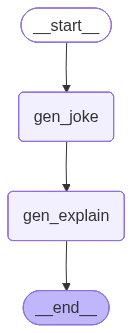

In [5]:
wfs

In [6]:

config1 = {"configurable": {"thread_id": "1"}}
wfs.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why was the pizza chef really good at his job? Because he always knew how to "top" it off with the perfect punchline!',
 'explain': 'This joke plays on the double meaning of the word "top," which can refer to both adding toppings to a pizza and delivering a great punchline in a joke or conversation. The joke suggests that the pizza chef is great at his job because he is not only skilled at adding delicious toppings to pizzas, but also knows how to "top" off his interactions with others by delivering the perfect punchline. This clever wordplay adds humor to the joke and highlights the chef\'s ability to excel in multiple areas, both in pizza-making and in social interactions.'}

In [7]:
wfs.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza chef really good at his job? Because he always knew how to "top" it off with the perfect punchline!', 'explain': 'This joke plays on the double meaning of the word "top," which can refer to both adding toppings to a pizza and delivering a great punchline in a joke or conversation. The joke suggests that the pizza chef is great at his job because he is not only skilled at adding delicious toppings to pizzas, but also knows how to "top" off his interactions with others by delivering the perfect punchline. This clever wordplay adds humor to the joke and highlights the chef\'s ability to excel in multiple areas, both in pizza-making and in social interactions.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14086c-f681-6935-8002-cfc43fa9edec'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-25T09:11:57.469690+00:00', parent_config={'configurable': 

In [8]:
wfs.get_state_history(config1)

<generator object Pregel.get_state_history at 0x0000016FC55C5900>

In [9]:
config2 = {"configurable": {"thread_id": "2"}}
wfs.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the pasta chef break up with his girlfriend?\n\nBecause she was too saucy for him to handle!',
 'explain': 'This joke plays on the dual meaning of "saucy," which can refer to someone who is flirtatious or sassy, as well as to pasta sauces. In this case, the pasta chef broke up with his girlfriend because she was too sassy or bold for him to handle, but also because being a pasta chef, he couldn\'t handle her sauciness (sauces) in the kitchen. It\'s a playful and punny way of suggesting that the girlfriend\'s bold personality was too much for the pasta chef to deal with.'}

In [10]:
wfs.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza chef really good at his job? Because he always knew how to "top" it off with the perfect punchline!', 'explain': 'This joke plays on the double meaning of the word "top," which can refer to both adding toppings to a pizza and delivering a great punchline in a joke or conversation. The joke suggests that the pizza chef is great at his job because he is not only skilled at adding delicious toppings to pizzas, but also knows how to "top" off his interactions with others by delivering the perfect punchline. This clever wordplay adds humor to the joke and highlights the chef\'s ability to excel in multiple areas, both in pizza-making and in social interactions.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14086c-f681-6935-8002-cfc43fa9edec'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-25T09:11:57.469690+00:00', parent_config={'configurable': 

In [11]:
wfs.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta chef break up with his girlfriend?\n\nBecause she was too saucy for him to handle!', 'explain': 'This joke plays on the dual meaning of "saucy," which can refer to someone who is flirtatious or sassy, as well as to pasta sauces. In this case, the pasta chef broke up with his girlfriend because she was too sassy or bold for him to handle, but also because being a pasta chef, he couldn\'t handle her sauciness (sauces) in the kitchen. It\'s a playful and punny way of suggesting that the girlfriend\'s bold personality was too much for the pasta chef to deal with.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f14086d-728b-6efb-8002-67c21718e3f3'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-25T09:12:10.476282+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f14086d-62de-632e-8001-1daffee510e8'}}, 